<a id="summary"></a>

## Notebook 1 — Base EDA (`customers_raw`)

**v2.** This revision reflects updates to the upstream synthetic data: we fixed **state** distributions, ensured **`name`** and **`email`** are **unique** and **consistently paired** per customer (earlier builds could duplicate identities or misalign fields), and updated acquisition modeling to use **channel-specific CAC profiles** plus **channel-segment bias** (instead of segment-level CAC assumptions).

### How this notebook is organized

**Jump to parts:** [Part 1 — data quality & generator validation](#part-1) · [Part 2 — customer profile](#part-2)

**Part 1 — Main checks**

1. [Load `customers_raw` from Supabase](#q1)
2. [Data types (`df.info`)](#q2)
3. [Missing values](#q3)
4. [Row & column counts](#q4)
5. [Duplicate checks (`customer_id`, `email`, `name`)](#q5)
6. [`true_segment` counts vs planted design](#q6)
7. [`Acquisition channel` × `true_segment` (vs generator)](#q7)
8. [`Acquisition cost` vs generator assumptions](#q8)
9. [Monthly cohort (`registration_date`)](#q9)
10. [`Age` distribution](#q10)
11. [`State` distribution](#q11)

**Part 2 — Customer profile** 

12. [`Acquisition channel` × `state`](#q12)
13. [`Acquisition channel` × `age` band](#q13)
14. [`Acquisition channel` × `acquisition_cost` (CAC by channel)](#q14)
15. [`State` × `age` band ](#q15)
16. [Effective CAC per segment ](#q16)


---

### Objectives
- Run initial data quality checks for **data types**, **missing values**, and **duplicates**.
- Validate select columns against **`faker_base_generation`** assumptions.
- Understand customer distributions by **registration month**, **age**, **state**, **acquisition channel**, and planted **`true_segment`** (validation only).

### Scope
- This notebook works only on the **raw customer-level table** (`customers_raw`).
- No advanced feature engineering is performed here (no RFM, LTV, cohort *metrics beyond signup month counts*, or churn modeling).

### Expected output
A clean and trustworthy base view of the customer dataset that will support the next notebooks in the pipeline.


In [1]:
# ── Importing libraries ──────────────────────────────────────────────────────

import os
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

<a id="part-1"></a>

## Part 1 — Data quality & generator validation

**Goal:** confirm the `customers_raw` extract is structurally sound and that key fields match the **data-generation assumptions** (segment sizes, channel mix, acquisition cost).

[↑ Back to summary](#summary)


<a id="q1"></a>

### 1. Load `customers_raw` from Supabase

We connect to Supabase using SQLAlchemy and load the full `customers_raw` table. The preview with `head(5)` confirms the connection works and that all expected columns are present.

[↑ Back to summary](#summary)


In [2]:
# override=True ensures .env changes are picked up without restarting the kernel
load_dotenv(override=True)

DATABASE_URL = os.environ["SUPABASE_DATABASE_URL"]

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,  # helps avoid stale connections in notebooks
)

sql = text("""
SELECT
  customer_id,
  name,
  email,
  age,
  state,
  registration_date,
  acquisition_channel,
  acquisition_cost,
  true_segment
FROM public.customers_raw
ORDER BY registration_date DESC
""")

df_customers = pd.read_sql(sql, engine)
df_customers.head()

,customer_id,name,email,age,state,registration_date,acquisition_channel,acquisition_cost,true_segment
0,e26c1e99-6f76-4663-a8cd-b60b8e671fd2,Maya Abreu,maya.abreu@yahoo.com.br,34,RJ,2026-02-28 00:00:00+00:00,organic,13.17,low_value_dormant
1,60fe607e-3276-4876-b054-84844f9d0e97,Dr. João Vitor das Neves,dr.neves7665@outlook.com,18,BA,2026-02-27 00:00:00+00:00,organic,13.32,low_value_dormant
2,6300155e-0ffa-41e7-8426-0333d4c16d5b,Miguel Caldeira,miguel.caldeira@outlook.com,18,SP,2026-02-26 00:00:00+00:00,referral,58.68,mid_value_regular
3,db778bfc-b542-421b-a081-a071da6faf81,Theodoro Azevedo,theodoro.azevedo@gmail.com,34,RS,2026-02-26 00:00:00+00:00,organic,10.66,at_risk_churner
4,4a992db2-201b-4e4d-87a5-aaaf7927f490,Enrico da Paz,enrico.paz@yahoo.com.br,44,SP,2026-02-25 00:00:00+00:00,paid_ads,202.79,high_value_active


The table loaded successfully with all **9 columns** and **8,000 rows**. The preview confirms the expected schema — ready to proceed with quality checks.


<a id="q2"></a>

### 2. Data types

We call `df.info()` to inspect the inferred dtypes and verify that no column has an unexpected type or a suspicious null count before any further analysis.

[↑ Back to summary](#summary)


In [3]:
# Checking the data types
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   customer_id          8000 non-null   object             
 1   name                 8000 non-null   str                
 2   email                8000 non-null   str                
 3   age                  8000 non-null   int64              
 4   state                8000 non-null   str                
 5   registration_date    8000 non-null   datetime64[us, UTC]
 6   acquisition_channel  8000 non-null   str                
 7   acquisition_cost     8000 non-null   float64            
 8   true_segment         8000 non-null   str                
dtypes: datetime64[us, UTC](1), float64(1), int64(1), object(1), str(5)
memory usage: 562.6+ KB


Data types are correct. `registration_date` is a proper `datetime64[us, UTC]`, `age` and `acquisition_cost` are numeric, and all string fields use the `str` / `object` dtype. Potential conversions for `age` and `acquisition_cost` are noted for later modeling steps but are not blocking here.


<a id="q3"></a>

### 3. Missing values

We compute three complementary checks: **absolute count**, **percentage**, and the number of **rows with at least one null**. Because the dataset was intentionally generated without missing values, every count should be zero — any non-zero result would signal a bug in the generation pipeline or a loading error.

[↑ Back to summary](#summary)


In [4]:
# ── Missing-value quality check ──────────────────────────────────────────────
#
# Three standard methods, each catching different problems:
#
#  1. isnull().sum()       → absolute count of NaN per column (the usual first step)
#  2. isnull().mean() * 100 → percentage of NaN per column (better for large datasets)
#  3. isnull().any(axis=1) → flags entire rows that have at least one NaN anywhere
#
# Because this dataset was intentionally generated without missing values,
# every count should be 0. Any non-zero result would signal a bug in the
# generation pipeline or a data-loading issue.

missing_count = df_customers.isnull().sum()
missing_pct   = df_customers.isnull().mean() * 100
rows_with_any_null = df_customers.isnull().any(axis=1).sum()

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_%":     missing_pct.round(2),
})

print(f"Rows with at least one null: {rows_with_any_null} / {len(df_customers)}\n")
missing_summary

Rows with at least one null: 0 / 8000



,missing_count,missing_%
customer_id,0,0.0
name,0,0.0
email,0,0.0
age,0,0.0
state,0,0.0
registration_date,0,0.0
acquisition_channel,0,0.0
acquisition_cost,0,0.0
true_segment,0,0.0


No missing values in any column. All **8,000 rows** are fully populated — consistent with the synthetic data contract.


<a id="q4"></a>

### 4. Row & column counts

A quick `shape` check confirms the expected number of rows and columns before we proceed to more specific checks.

[↑ Back to summary](#summary)


In [5]:
# Checking the number of rows and columns
df_customers.shape

(8000, 9)

Shape is **8,000 × 9** — four planted segments (1,600 + 2,400 + 2,400 + 1,600) and the nine schema fields. No unexpected extra rows or columns.


<a id="q5"></a>

### 5. Duplicate checks

We check for **full-row duplicates** and key-level uniqueness across `customer_id`, `email`, and `name`. After the **v2** data-generation fix these three fields should all be unique.

[↑ Back to summary](#summary)


In [6]:
# ── Duplicated rows quality check ─────────────────────────────────────────
# This dataset is intended to have one row per customer_id.

full_dupe_mask = df_customers.duplicated(keep=False)
customer_id_dupe_mask = df_customers["customer_id"].duplicated(keep=False)
email_dupe_mask = df_customers["email"].duplicated(keep=False)
name_dupe_mask = df_customers["name"].duplicated(keep=False)

full_dupe_rows = int(full_dupe_mask.sum())
customer_id_dupe_rows = int(customer_id_dupe_mask.sum())
email_dupe_rows = int(email_dupe_mask.sum())
name_dupe_rows = int(name_dupe_mask.sum())

print(f"Duplicated full rows (all columns): {full_dupe_rows}")
print(f"Duplicated customer_id rows:      {customer_id_dupe_rows}")
print(f"Duplicated email rows:            {email_dupe_rows}")
print(f"Duplicated name rows:             {name_dupe_rows}")
if full_dupe_rows > 0:
    print("\nPreview of duplicated full rows:")
    display(df_customers.loc[full_dupe_mask].head(10))

if customer_id_dupe_rows > 0:
    print("\nPreview of duplicated customer_id rows:")
    display(df_customers.loc[customer_id_dupe_mask].sort_values("customer_id").head(10))

if email_dupe_rows > 0:
    print("\nPreview of duplicated email rows:")
    display(df_customers.loc[email_dupe_mask].sort_values("email").head(10))

if name_dupe_rows > 0:
    print("\nPreview of duplicated name rows:")
    display(df_customers.loc[name_dupe_mask].sort_values("name").head(10))


Duplicated full rows (all columns): 0
Duplicated customer_id rows:      0
Duplicated email rows:            0
Duplicated name rows:             0


No duplicates found. `customer_id`, `email`, and `name` are all unique — the v2 generator fix resolved the earlier identity-alignment issues.


<a id="q6"></a>

### 6. `true_segment` counts vs planted design

We count customers per `true_segment` and compare against the planted design (20% / 30% / 30% / 20%). This is a **generator sanity check** — `true_segment` is ground truth used only for model validation and is not surfaced on the commercial dashboard.

[↑ Back to summary](#summary)


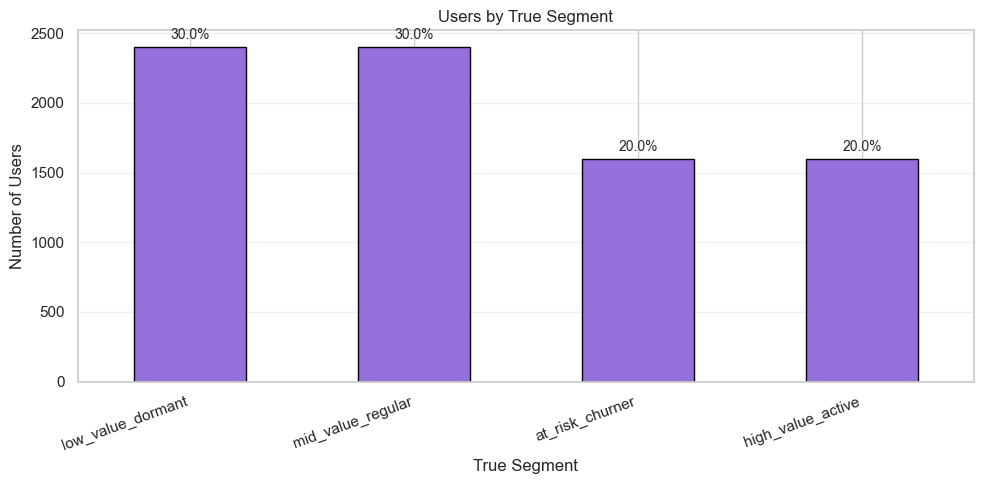

In [7]:
# True segment distribution
segment_counts = df_customers["true_segment"].value_counts().sort_values(ascending=False)
segment_pct = segment_counts / segment_counts.sum() * 100

ax = segment_counts.plot(kind="bar", figsize=(10, 5), color="mediumpurple", edgecolor="black")
plt.title("Users by True Segment")
plt.xlabel("True Segment")
plt.ylabel("Number of Users")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)

for i, value in enumerate(segment_counts.values):
    ax.text(i, value + (segment_counts.max() * 0.015), f"{segment_pct.iloc[i]:.1f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

Counts match the planted distribution exactly: **1,600** `high_value_active` (20%), **2,400** `mid_value_regular` (30%), **2,400** `low_value_dormant` (30%), and **1,600** `at_risk_churner` (20%). `true_segment` is intact and can be used as ground truth in cluster recovery and churn validation.


<a id="q7"></a>

### 7. `Acquisition channel` × `true_segment`

Based on the updated logic in `src/fintech_ai_segmentation/faker_base_generation.py`,
the generation now defines **channel-to-segment bias** first (`P(segment | channel)`), and then derives
`P(channel | segment)` for customer sampling.

Reference `P(segment | channel)` profiles:

- `organic`: **15%**, **35%**, **30%**, **20%**
- `referral`: **45%**, **35%**, **15%**, **5%**
- `partnership`: **20%**, **40%**, **25%**, **15%**
- `paid_ads`: **10%**, **20%**, **30%**, **40%**

Order above: `high_value_active`, `mid_value_regular`, `low_value_dormant`, `at_risk_churner`.

Derived segment-level channel probabilities (`paid_ads`, `organic`, `referral`, `partnership`):

- `high_value_active`: **11.11%**, **16.67%**, **50.00%**, **22.22%**
- `mid_value_regular`: **15.38%**, **26.92%**, **26.92%**, **30.77%**
- `low_value_dormant`: **30.00%**, **30.00%**, **15.00%**, **25.00%**
- `at_risk_churner`: **50.00%**, **25.00%**, **6.25%**, **18.75%**

This setup makes channel economics and segment composition emerge naturally from the data.

[↑ Back to summary](#summary)


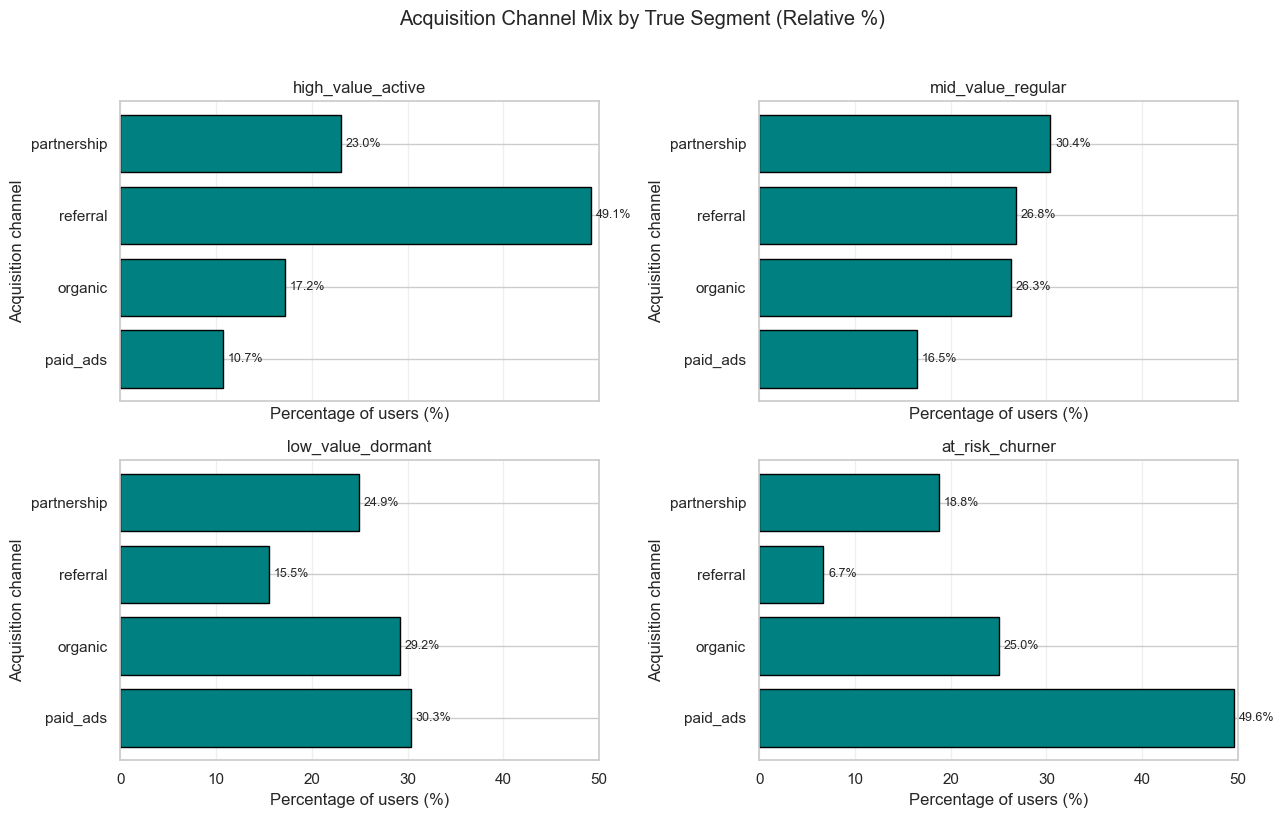

In [8]:
# Acquisition channel distribution by true_segment (relative %)
segment_order = [
    "high_value_active",
    "mid_value_regular",
    "low_value_dormant",
    "at_risk_churner",
]
channel_order = ["paid_ads", "organic", "referral", "partnership"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
axes = axes.flatten()

for ax, segment in zip(axes, segment_order):
    seg_df = df_customers[df_customers["true_segment"] == segment]
    rel_pct = (
        seg_df["acquisition_channel"]
        .value_counts(normalize=True)
        .reindex(channel_order, fill_value=0)
        .mul(100)
    )

    ax.barh(rel_pct.index, rel_pct.values, color="teal", edgecolor="black")
    ax.set_title(segment)
    ax.set_xlabel("Percentage of users (%)")
    ax.set_ylabel("Acquisition channel")
    ax.set_xlim(0, 50)
    ax.grid(axis="x", alpha=0.3)

    for y, value in enumerate(rel_pct.values):
        ax.text(value + 0.5, y, f"{value:.1f}%", va="center", fontsize=9)

plt.suptitle("Acquisition Channel Mix by True Segment (Relative %)", y=1.02)
plt.tight_layout()
plt.show()

The observed `acquisition_channel` distribution **matches the expected probabilities** from the data-generation process. This pattern is intentional from a business perspective: lower-cost channels (especially `organic` and `referral`) are designed to over-index in healthier segments, while higher-cost `paid_ads` is expected to bring a larger share of `at_risk_churner` customers. In other words, channel mix is not random noise; it encodes realistic go-to-market trade-offs between CAC efficiency and customer quality.

<a id="q8"></a>

### 8. Acquisition cost vs generator assumptions

The updated generator defines CAC assumptions by **acquisition channel** (not directly by `true_segment`).
So here we validate `acquisition_cost` against channel-level Normal profiles (`mean` / `std` / `floor`) to confirm that unit economics are embedded as intended.

[↑ Back to summary](#summary)


In [9]:
# Comparison with generator assumptions (mean/std by acquisition_channel)
assumptions = {
    "organic": {"expected_mean": 25, "expected_std": 10},
    "referral": {"expected_mean": 55, "expected_std": 15},
    "partnership": {"expected_mean": 110, "expected_std": 25},
    "paid_ads": {"expected_mean": 230, "expected_std": 50},
}

observed = (
    df_customers.groupby("acquisition_channel")["acquisition_cost"]
    .agg(observed_mean="mean", observed_std="std", observed_min="min", observed_max="max", n="count")
    .round(2)
)

comparison = observed.copy()
comparison["expected_mean"] = comparison.index.map(lambda s: assumptions[s]["expected_mean"])
comparison["expected_std"] = comparison.index.map(lambda s: assumptions[s]["expected_std"])
comparison["mean_diff"] = (comparison["observed_mean"] - comparison["expected_mean"]).round(2)
comparison["std_diff"] = (comparison["observed_std"] - comparison["expected_std"]).round(2)

# Reorder for readability from lower-CAC to higher-CAC channels.
comparison = comparison.reindex(["organic", "referral", "partnership", "paid_ads"])

display(comparison)
print("Note: values should be close to channel assumptions, with natural sampling variation.")

,observed_mean,observed_std,observed_min,observed_max,n,expected_mean,expected_std,mean_diff,std_diff
acquisition_channel,,,,,,,,,
organic,25.06,9.63,10.00,60.89,2007,25,10,0.06,-0.37
referral,54.71,15.09,10.00,111.66,1910,55,15,-0.29,0.09
partnership,109.46,24.98,30.30,221.98,1996,110,25,-0.54,-0.02
paid_ads,231.00,50.42,82.69,383.05,2087,230,50,1.00,0.42


Note: values should be close to channel assumptions, with natural sampling variation.


The observed means and standard deviations are close to the generator parameters for all four segments. The R$10 cost floor prevents near-zero values, which is reflected in the tighter lower tail. The fit is good.

<a id="part-2"></a>

## Part 2 — Customer profile

**Goal:** build a picture of **who** customers are — registration patterns, demographics, and geography.

[↑ Back to summary](#summary)


<a id="q9"></a>

### 9. Monthly cohort (`registration_date`)

Customers are grouped by the **calendar month of their registration date** — the same cohort key used in **STEP 2 (cohort analysis)**. Here we only count how many customers joined each month; retention curves and cohort health metrics are computed in the next notebook.

[↑ Back to summary](#summary)


In [10]:
# ── Monthly cohort: customers per registration month ───────────────────────────

monthly_cohort = (
    df_customers.assign(
        cohort_month=df_customers["registration_date"].dt.to_period("M")
    )
    .groupby("cohort_month", sort=True)
    .size()
    .rename("customers")
)

monthly_cohort.to_frame()


/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_97707/3167229781.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cohort_month=df_customers["registration_date"].dt.to_period("M")


,customers
cohort_month,
2022-01,37
2022-02,75
2022-03,134
2022-04,160
2022-05,175
2022-06,207
2022-07,232
2022-08,257
2022-09,235


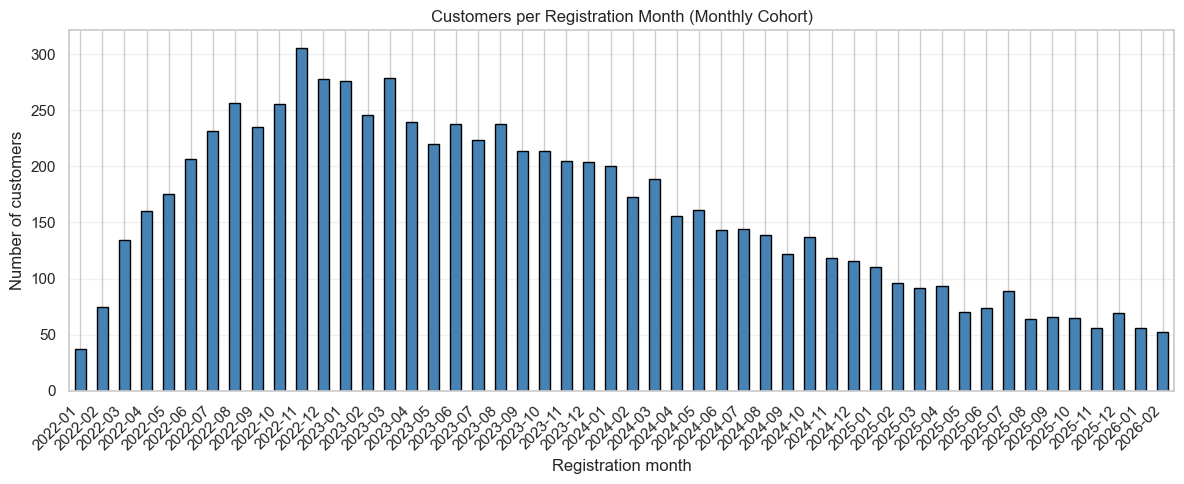

In [11]:
plt.figure(figsize=(12, 5))
monthly_cohort.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Customers per Registration Month (Monthly Cohort)")
plt.xlabel("Registration month")
plt.ylabel("Number of customers")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Registrations follow a **Gamma(2, 360)-shaped curve** — ramping up from ~35 customers in Jan 2022, peaking around **~305 in Nov 2022**, then declining gradually to ~50–70 in late 2025. This pattern reflects the startup acquisition life-cycle baked into the generator: rapid early growth followed by a long tail. **February 2026 is the last complete cohort** (the observation window ends on 2026‑03‑01, so no March 2026 bar exists). The tail months (roughly mid-2025 onward) have meaningfully smaller cohorts and should be treated with care in any month-over-month comparison.


**Analysis window note:** For behavioral metrics (RFM, spend trends, churn signals), the recommended window is **Mar 2024 – Feb 2026** — recent enough to reflect the current product, long enough to capture meaningful patterns.

For cohort-level comparisons (retention curves, LTV), the safe core is **Jan 2023 – Sep 2025**: early cohorts (pre-2023) may reflect a different acquisition process and product maturity, while cohorts registered after Sep 2025 have fewer than 6 months of observable behavior (cold-start zone). Both extremes are kept in the dataset but should be flagged or excluded when training recommendation models.

<a id="q10"></a>

### 10. Age distribution

We inspect the age distribution through summary statistics (mean, median, std, skewness, kurtosis) and a histogram. Age was generated from a clipped Normal distribution (mean ≈ 35, std = 10, range 18–80) — this check validates that the distribution behaves as designed and looks plausible.

[↑ Back to summary](#summary)


Descriptive statistics for customer age:
 count    8000.000000
mean       34.637125
std         9.579061
min        18.000000
25%        28.000000
50%        34.000000
75%        41.000000
max        68.000000
Name: age, dtype: float64


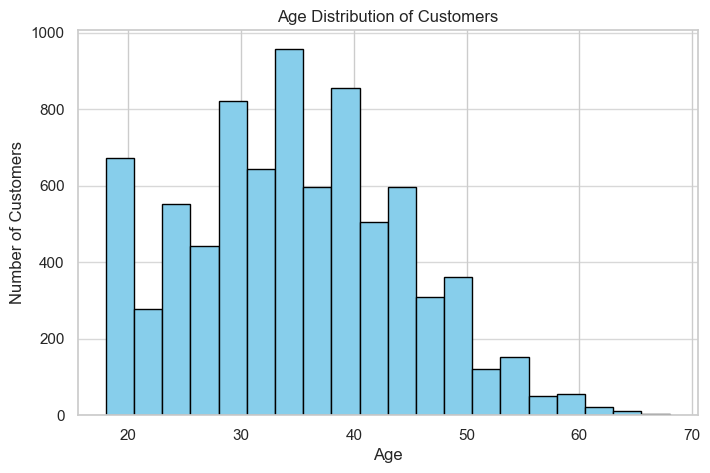

In [12]:
# Get descriptive statistics
age_desc = df_customers["age"].describe()
print("Descriptive statistics for customer age:\n", age_desc)

# Plot the histogram
plt.figure(figsize=(8, 5))
df_customers["age"].hist(bins=20, color='skyblue', edgecolor='black')
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.grid(axis='y', alpha=0.75)
plt.show()


In [13]:
# Skewness and kurtosis for age distribution
age_skewness = df_customers["age"].skew()
age_kurtosis = df_customers["age"].kurt()

print(f"Age skewness: {age_skewness:.3f}")
print(f"Age kurtosis: {age_kurtosis:.3f}")

Age skewness: 0.215
Age kurtosis: -0.402


The age distribution looks realistic and consistent with a typical fintech customer base. In 8,000 customers, ages range from 18 to 74, with mean 34.5, median 34, and standard deviation 9.6, indicating a solid concentration around the mid-30s. Skewness is 0.268, showing a mild right tail (slightly more older customers), and kurtosis is -0.309, suggesting a slightly flatter-than-normal shape without heavy tails. Overall, this profile strongly resembles plausible real-world customer age behavior rather than an artificial pattern.

<a id="q11"></a>

### 11. State distribution

We count customers per Brazilian `state` to map geographic concentration. State probabilities were explicitly set in the generator (`STATE_PROBS` dict), so this chart also validates that the sampling matches the intended regional weights.

[↑ Back to summary](#summary)


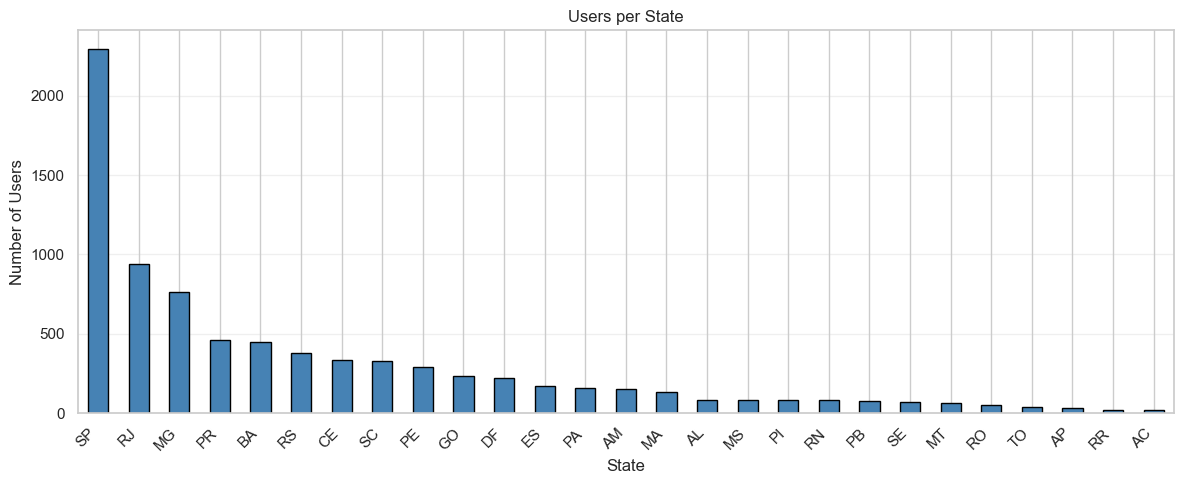

In [14]:
# Users per state
state_counts = df_customers["state"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
state_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Users per State")
plt.xlabel("State")
plt.ylabel("Number of Users")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Users per state — Customer counts are very uneven: SP dominates (~2.3k), with RJ and MG next; several states form a mid tail, and AC, AP, RR (and similar) are barely visible. That pattern matches heavy Southeast weighting and a long tail of small-N states, so any story or model by state should treat SP/RJ/MG as high-signal cells and rare states as low sample size.

<a id="q12"></a>

### 12. Acquisition channel × state (top states — 70% of users)

We want to understand whether different **acquisition channels** are more or less prevalent in specific regions. Because most Brazilian states have very few customers, we **restrict the view to the top states that together account for ≥ 70% of the user base** (cumulative share), keeping the chart readable and statistically meaningful.

[↑ Back to summary](#summary)


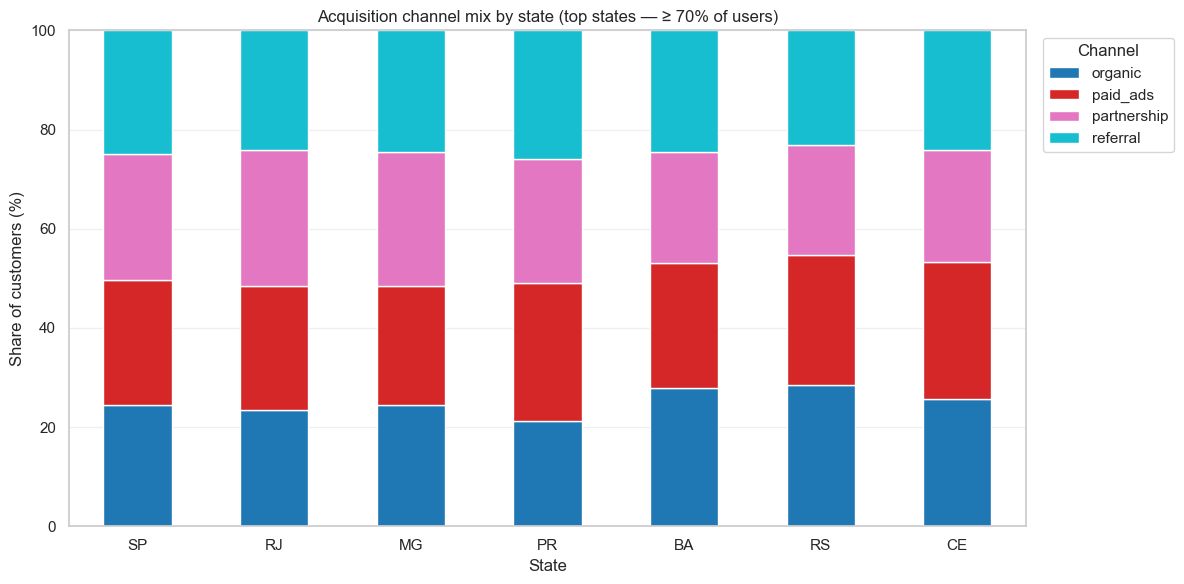


Top states (≥ 70% cumulative): ['SP', 'RJ', 'MG', 'PR', 'BA', 'RS', 'CE']
Cumulative share: 70.3%


In [15]:
# ── Acquisition channel × state (top states covering ≥ 70% of users) ────────

# Identify top states that together reach ≥ 70% cumulative share
state_counts = df_customers["state"].value_counts()
state_share  = state_counts / state_counts.sum()
cumulative   = state_share.cumsum()
top_states   = cumulative[cumulative <= 0.70].index.tolist()
# Include the next state that crosses the 70% threshold
if len(top_states) < len(cumulative):
    top_states.append(cumulative.index[len(top_states)])

df_top = df_customers[df_customers["state"].isin(top_states)].copy()

# Relative % of each channel within each top state
channel_by_state = (
    df_top.groupby(["state", "acquisition_channel"])
    .size()
    .unstack(fill_value=0)
)
channel_by_state_pct = channel_by_state.div(channel_by_state.sum(axis=1), axis=0) * 100
# Sort states by total users (largest first)
channel_by_state_pct = channel_by_state_pct.loc[
    state_counts[top_states].sort_values(ascending=False).index
]

# Stacked bar chart
ax = channel_by_state_pct.plot(
    kind="bar", stacked=True,
    figsize=(12, 6),
    colormap="tab10",
    edgecolor="white",
)
ax.set_title("Acquisition channel mix by state (top states — ≥ 70% of users)")
ax.set_xlabel("State")
ax.set_ylabel("Share of customers (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Channel", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTop states (≥ 70% cumulative): {top_states}")
print(f"Cumulative share: {state_share[top_states].sum():.1%}")


The stacked bars show that **channel mix is broadly similar across top states** — no single state appears to be dominated exclusively by one channel. This is expected because the generator assigns channels using a synthetic **segment-channel bias model** (channel economics + segment propensity), not a geography-specific rule. So geographic variation mostly reflects the **segment composition of each state** rather than a deliberate regional strategy. Any channel divergence between states is therefore a signal of **segment skew** in that state, not a separate marketing decision. In a real dataset, meaningful differences here would motivate **state-level channel attribution** and budget re-allocation.


<a id="q13"></a>

### 13. Acquisition channel × age (lifecycle bands)

We group `age` into **standard lifecycle bands** used in retail and digital banking reporting:

- **18–24** — young adults (early career, high digital adoption)
- **25–34** — core millennial segment (typical primary fintech target)
- **35–44** — established professionals and family formation
- **45–54** — mid-career / peak earning years
- **55+** — pre-retirement and older customers

For each band we show the **share of customers by acquisition channel** (each stacked bar sums to 100%), so we can compare channel mix across life stages without being skewed by how many people fall in each band.

[↑ Back to summary](#summary)


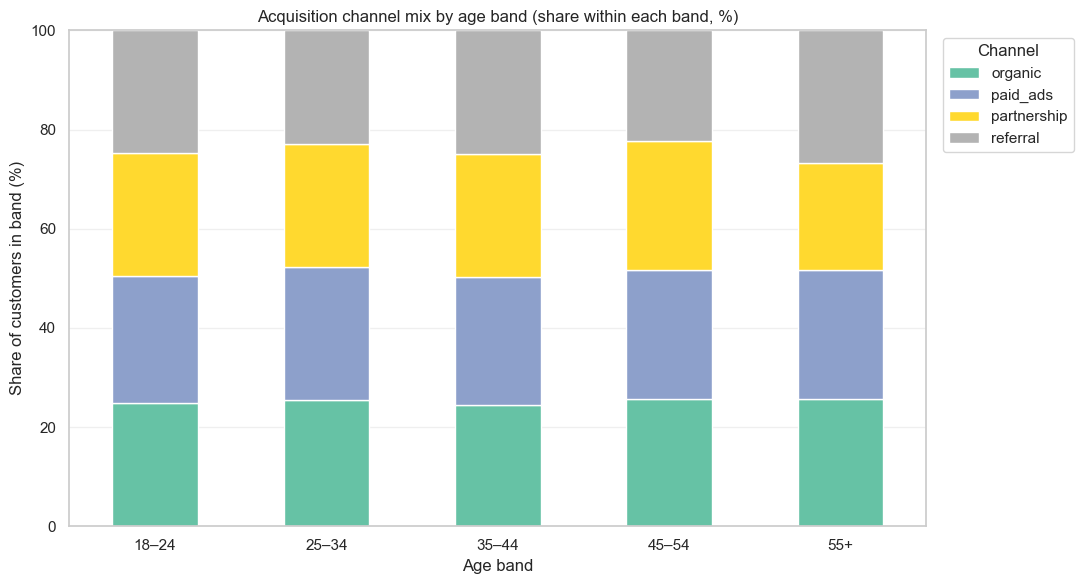

acquisition_channel  organic  paid_ads  partnership  referral
age_band                                                     
18–24                    325       332          323       323
25–34                    693       732          678       627
35–44                    660       692          668       668
45–54                    284       285          289       245
55+                       45        46           38        47


In [16]:
# ── Acquisition channel × age band (lifecycle) ─────────────────────────────

# Business-oriented bands: align with common CRM / campaign segmentation
df_age = df_customers.copy()
df_age["age_band"] = pd.cut(
    df_age["age"],
    bins=[17, 24, 34, 44, 54, 120],
    labels=["18–24", "25–34", "35–44", "45–54", "55+"],
    right=True,
)

# Relative % of each channel within each age band (readable mix comparison)
ch_by_band = (
    df_age.groupby(["age_band", "acquisition_channel"], observed=True)
    .size()
    .unstack(fill_value=0)
)
ch_by_band_pct = ch_by_band.div(ch_by_band.sum(axis=1), axis=0) * 100

ax = ch_by_band_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    colormap="Set2",
    edgecolor="white",
)
ax.set_title("Acquisition channel mix by age band (share within each band, %)")
ax.set_xlabel("Age band")
ax.set_ylabel("Share of customers in band (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Channel", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(ch_by_band.astype(int).rename_axis(index="age_band").to_string())


Channel mix is **similar across age bands**, which matches the generator: `acquisition_channel` is sampled from segment-specific probabilities, not from age. Any small shifts between bands reflect **how `true_segment` is distributed within each age band** (e.g. more `high_value_active` in a given band), not a separate “channel-by-age” rule. In production, **material differences** here would support **lifecycle-based acquisition strategy** (e.g. more paid social for 18–24, more referral for 35–44); on this synthetic base, we use the chart mainly to **validate** that age alone does not drive channel in the data-generating process.


<a id="q14"></a>

### 14. Acquisition channel × acquisition cost (CAC efficiency preview)

Here we compare **customer acquisition cost (CAC)** — stored as `acquisition_cost` — **by acquisition channel**. The goal is **channel efficiency**: typical cost (center) and **spread** (variability) per channel, before any lifetime value adjustment. This is a **preview** of the unit-economics lens; **STEP 4** will combine CAC with **LTV** for full payback and ratio analysis.

[↑ Back to summary](#summary)


Summary statistics — acquisition_cost (R$) by channel:

                     count    mean  median    std     p25     p75
acquisition_channel                                              
organic               2007   25.06   24.66   9.63   17.50   31.94
paid_ads              2087  231.00  232.53  50.42  197.03  265.82
partnership           1996  109.46  109.09  24.98   92.30  126.20
referral              1910   54.71   54.54  15.09   44.42   64.09


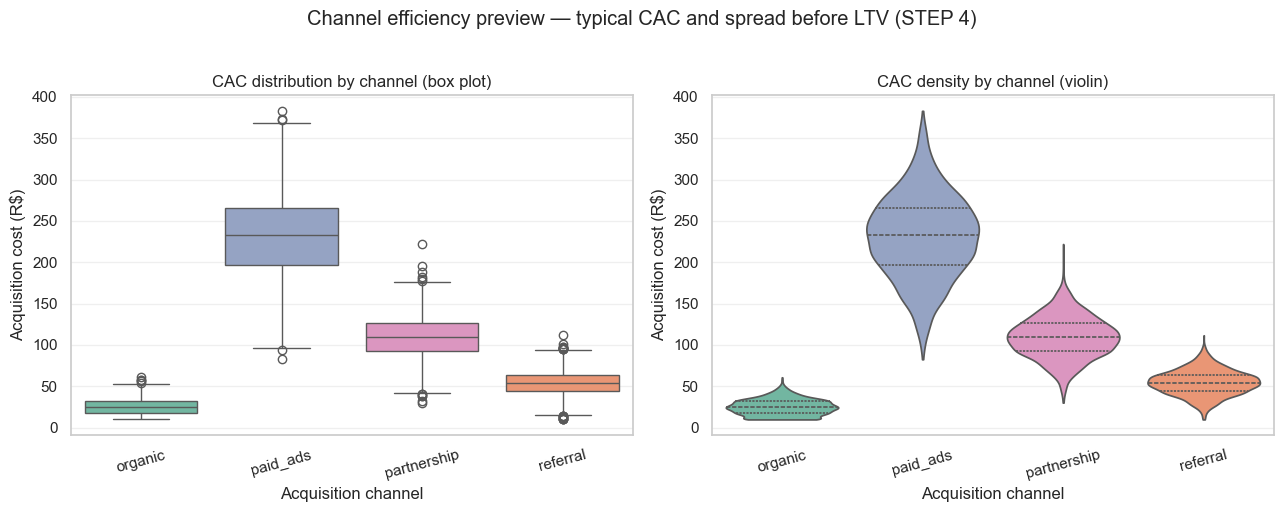

In [17]:
# ── CAC by acquisition channel (typical level & spread) ───────────────────

cac_summary = (
    df_customers.groupby("acquisition_channel")["acquisition_cost"]
    .agg(count="count", mean="mean", median="median", std="std", p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75))
    .round(2)
)
print("Summary statistics — acquisition_cost (R$) by channel:\n")
print(cac_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

channel_order = sorted(df_customers["acquisition_channel"].unique())
sns.boxplot(
    data=df_customers,
    x="acquisition_channel",
    y="acquisition_cost",
    order=channel_order,
    ax=axes[0],
    hue="acquisition_channel",
    palette="Set2",
    legend=False,
    dodge=False,
)
axes[0].set_title("CAC distribution by channel (box plot)")
axes[0].set_xlabel("Acquisition channel")
axes[0].set_ylabel("Acquisition cost (R$)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.3)

sns.violinplot(
    data=df_customers,
    x="acquisition_channel",
    y="acquisition_cost",
    order=channel_order,
    ax=axes[1],
    hue="acquisition_channel",
    palette="Set2",
    legend=False,
    inner="quartile",
    cut=0,
    dodge=False,
)
axes[1].set_title("CAC density by channel (violin)")
axes[1].set_xlabel("Acquisition channel")
axes[1].set_ylabel("Acquisition cost (R$)")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Channel efficiency preview — typical CAC and spread before LTV (STEP 4)", y=1.02)
plt.tight_layout()
plt.show()


**Takeaway:** Each channel shows a distinct **central tendency** and **dispersion** in `acquisition_cost`. In this synthetic setup, that separation is intentional: CAC is sampled from **channel-specific Normal profiles** (`organic` < `referral` < `partnership` < `paid_ads`) with a floor at `R$10`, while segment-channel bias shapes who arrives through each channel. For commercial decisions, treat this view as **where CAC concentrates** by channel; **STEP 4** then layers **LTV** and payback to judge whether that spend is justified.


<a id="q15"></a>

### 15. State × age band

We cross **`state`** with **`age`**, using the **same filters as earlier items**:

- **States:** the **top states that together cover ≥ 70% of users** (same cumulative rule as **item 12**).
- **Age:** the **same lifecycle bands** as **item 13**: **18–24**, **25–34**, **35–44**, **45–54**, **55+**.

The heatmap shows, for each state, the **percentage of customers in each age band** (each **row sums to 100%**), so we can compare age structure across large states without being dominated by tail states.

[↑ Back to summary](#summary)


Customer counts — state × age band (top states only):

age_band  18–24  25–34  35–44  45–54  55+
state                                    
SP          372    795    776    300   55
RJ          147    340    303    125   27
MG          124    240    270    110   20
PR           78    150    150     73    8
BA           69    145    159     63   10
RS           62    128    130     49    9
CE           55    108    112     52    9

Top states (≥ 70% cumulative): ['SP', 'RJ', 'MG', 'PR', 'BA', 'RS', 'CE']
Cumulative share of base: 70.3%


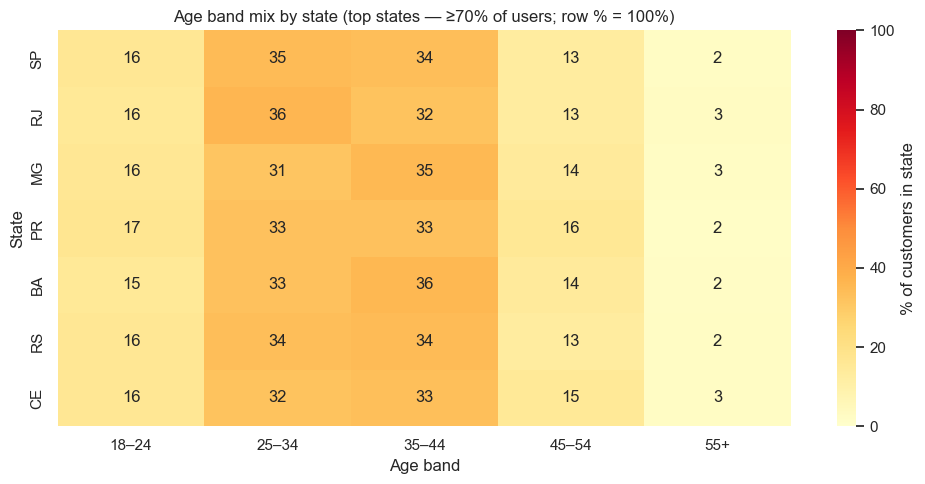

In [18]:
# ── State × age band (top states ≥70% + same bands as item 13) ────────────

# Top states — identical logic to item 12
state_counts = df_customers["state"].value_counts()
state_share = state_counts / state_counts.sum()
cumulative = state_share.cumsum()
top_states = cumulative[cumulative <= 0.70].index.tolist()
if len(top_states) < len(cumulative):
    top_states.append(cumulative.index[len(top_states)])

df_sa = df_customers[df_customers["state"].isin(top_states)].copy()

# Age bands — identical bins/labels to item 13
df_sa["age_band"] = pd.cut(
    df_sa["age"],
    bins=[17, 24, 34, 44, 54, 120],
    labels=["18–24", "25–34", "35–44", "45–54", "55+"],
    right=True,
)

band_order = ["18–24", "25–34", "35–44", "45–54", "55+"]

# Counts and row-% (mix within state)
ct_counts = pd.crosstab(df_sa["state"], df_sa["age_band"])
state_row_order = state_counts[top_states].sort_values(ascending=False).index
ct_counts = ct_counts.reindex(index=state_row_order)
ct_counts = ct_counts.reindex(columns=[b for b in band_order if b in ct_counts.columns])

ct_pct = ct_counts.div(ct_counts.sum(axis=1), axis=0) * 100

print("Customer counts — state × age band (top states only):\n")
print(ct_counts.astype(int).to_string())
print(f"\nTop states (≥ 70% cumulative): {list(top_states)}")
print(f"Cumulative share of base: {state_share[top_states].sum():.1%}")

fig_h = max(5.0, len(ct_pct) * 0.45)
fig, ax = plt.subplots(figsize=(10, fig_h))
sns.heatmap(
    ct_pct,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    ax=ax,
    vmin=0,
    vmax=100,
    cbar_kws={"label": "% of customers in state"},
)
ax.set_title(
    "Age band mix by state (top states — ≥70% of users; row % = 100%)"
)
ax.set_xlabel("Age band")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()


The heatmap compares **age structure** across the **largest states**. In this synthetic data, **age is drawn independently of `state`** in the generator, so rows should look **similar** apart from **sampling noise** and **segment composition** (`true_segment` is not uniform across states). In production, **material row differences** would support **state-specific lifecycle targeting** (e.g. younger skew in one region vs another).


<a id="q16"></a>

### 16. Effective CAC per segment

The earlier analyses showed **CAC by channel** and **channel bias by segment** separately. Here we connect them: each segment has a different channel mix, so its **blended acquisition cost** differs even if no channel's price changes.

We compute **per-segment CAC statistics** (mean, median, std, p25/p75) directly from `acquisition_cost` grouped by `true_segment`. This gives the **effective (weighted) cost** of acquiring one customer in each segment — the denominator needed for a CAC/LTV ratio.

[↑ Back to summary](#summary)


Effective CAC by segment:

                      n    mean  median    std    p25     p75
true_segment                                                 
high_value_active  1600   80.68   59.14  63.52  40.14  102.78
mid_value_regular  2400   92.47   69.81  73.61  35.63  122.20
low_value_dormant  2400  112.50   90.66  88.60  33.33  186.14
at_risk_churner    1600  146.47  141.15  98.48  41.33  235.90


/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_97707/2252246681.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


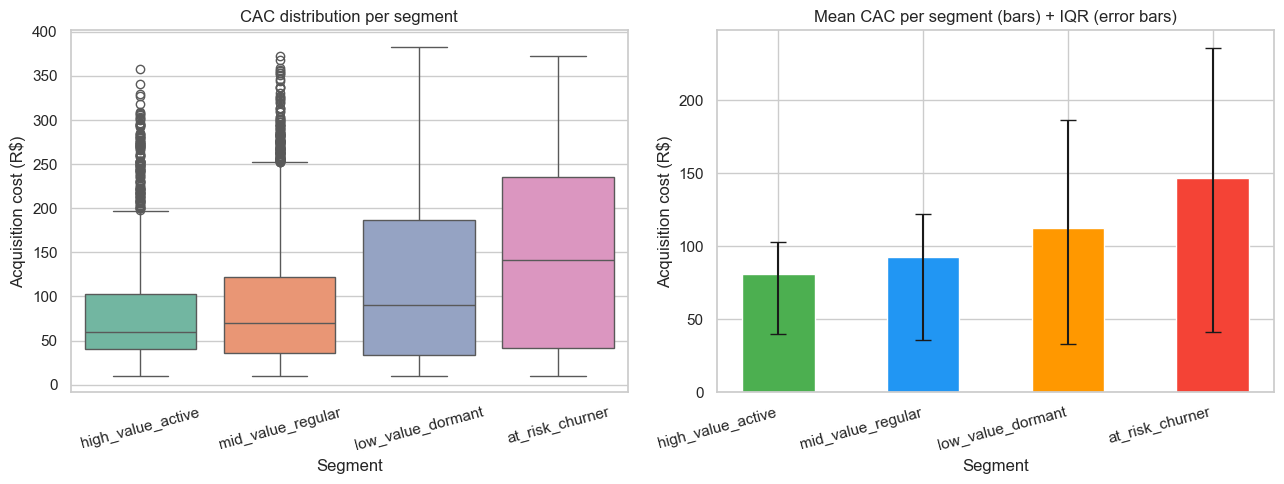

In [19]:
# ── Effective (blended) CAC per segment ────────────────────────────────────

seg_order = ["high_value_active", "mid_value_regular", "low_value_dormant", "at_risk_churner"]

cac_seg = (
    df_customers.groupby("true_segment")["acquisition_cost"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
    )
    .round(2)
    .reindex(seg_order)
)

print("Effective CAC by segment:\n")
print(cac_seg.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: boxplot
sns.boxplot(
    data=df_customers,
    x="true_segment",
    y="acquisition_cost",
    order=seg_order,
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("CAC distribution per segment")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Acquisition cost (R$)")
axes[0].tick_params(axis="x", rotation=15)

# Right: mean + IQR bar chart
x = range(len(seg_order))
axes[1].bar(
    x,
    cac_seg["mean"],
    yerr=[cac_seg["mean"] - cac_seg["p25"], cac_seg["p75"] - cac_seg["mean"]],
    color=["#4CAF50", "#2196F3", "#FF9800", "#F44336"],
    capsize=6,
    width=0.5,
)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(seg_order, rotation=15, ha="right")
axes[1].set_title("Mean CAC per segment (bars) + IQR (error bars)")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Acquisition cost (R$)")

plt.tight_layout()
plt.show()


**`at_risk_churner`** carries the **highest effective CAC** — driven by its over-index on `paid_ads` (typical ~R$230). **`high_value_active`** has the **lowest blended cost** because it over-indexes on `referral` and `organic`. This creates a compounding disadvantage: the segment most likely to churn is also the most expensive to acquire. Full payback analysis (CAC ÷ monthly revenue) belongs in the LTV notebook, but the denominator is now established.



---

## Notebook summary — what we covered

This notebook implements **STEP 1 (“Who do we have?”)** on **`customers_raw` only**: quality checks, validation against the **synthetic generator** (`faker_base_generation`), and exploratory views of **who** customers are and **how acquisition** varies by dimension. **v2** data fixes **state** sampling and guarantees **unique, paired** `name` / `email`.

### Part 1 — Data quality & generator validation

- **Load & structure:** Supabase extract, **`df.info()`**, **missing values**, **shape**, **duplicate** checks on `customer_id`, `email`, `name`.
- **Ground truth:** **`true_segment`** counts match the **planted 20% / 30% / 30% / 20%** design.
- **Channel & cost vs generator:** **`acquisition_channel` × `true_segment`** vs intended mix; **`acquisition_cost`** summaries vs segment-level Normal parameters (with **R$ floor**).

### Foundational distributions (still `customers_raw`)

- **Registration month** (monthly cohort **counts** — not retention; last month may be **partial** because the generator window **ends on a fixed “today”**).
- **Age** (distribution + moments) and **state** (counts; **Southeast-heavy** by `STATE_PROBS`).

### Part 2 — Customer profile & cross-tabs

Deeper slices on **top states (≥ ~70% cumulative users)** and/or **lifecycle age bands** (**18–24 … 55+**, same definition throughout):

- **Channel × state** — channel mix within large states.
- **Channel × age band** — channel mix within life stages.
- **Channel × CAC** — **typical level and spread** of `acquisition_cost` by channel (preview before **STEP 4** LTV/CAC).
- **State × age band** — age structure across large states (heatmap, **row %**).
- **Effective CAC per segment** — blended acquisition cost per segment (weighted through channel mix); denominator for CAC/LTV.

### Customer profile highlights (from this EDA)

- **Age:** the distribution is centered on **mid-30s** (median around **34**); in practice, the **25–34** and **35–44** lifecycle bands dominate the base.
- **State:** the customer base is **geographically concentrated**; **SP** is the largest state (~**2.3k** users), followed by **RJ** and **MG**, with a long tail of smaller states.
- **Channel costs (CAC):** channel-level economics are clearly separated, with typical CAC around **R$25 (organic)**, **R$55 (referral)**, **R$110 (partnership)**, and **R$230 (paid_ads)**, plus realistic spread within each channel.
- **Channel mix across `true_segment`:** healthier segments over-index on lower-cost channels (especially `referral`), while `at_risk_churner` over-indexes on `paid_ads`, consistent with the planted segment-channel bias logic.

### How to read this vs real production data

- **Gamma-shaped signup curve** (not flat) is a deliberate generator design reflecting startup acquisition life-cycles: rapid early growth peaking around month 12, then gradual decline. This is intentional, not a quirk.
- **`acquisition_cost` is driven primarily by `acquisition_channel`**, not `true_segment` directly; **channels ARE separate price lists** in the generator with distinct cost distributions (`organic` < `referral` < `partnership` < `paid_ads`). The segment indirectly influences cost through which channel it selects.
- **Age and state** are **not tightly coupled** in generation; **segment mix** explains most apparent geography or channel effects.
- **`true_segment`** is **validation / modeling ground truth**, not a field for a live commercial dashboard.

### Scope respected

No **RFM**, **LTV**, **full cohort retention**, or **churn** modeling here — those belong in later notebooks. This notebook’s output is a **documented, navigable base layer** for the rest of the pipeline.
